In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import joblib
import itertools

2026-03-03 14:52:41.917926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772549562.308236      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772549562.392774      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772549563.314622      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772549563.314657      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772549563.314660      55 computation_placer.cc:177] computation placer alr

#  1. Load & clean 


In [2]:
df = pd.read_excel('/kaggle/input/datasets/annapoornaak/dataset-ctg-mlp-classification/CTG.xls',
                   sheet_name='Raw Data', engine='xlrd')
df = df.dropna(subset=['NSP'])

drop_cols = ['FileName', 'Date', 'SegFile', 'NSP', 'CLASS',
             'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'DR']
X = df.drop(columns=drop_cols).apply(pd.to_numeric, errors='coerce').fillna(0)
y = df['NSP'].astype(int) - 1  # 0=Normal, 1=Suspect, 2=Pathologic

#  2. Split and Scale

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
n_features = X.shape[1]
print(f"Number of features: {n_features}")

#  3. Class weights 


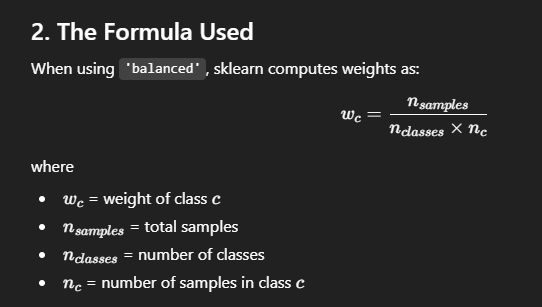

In [4]:
# Class weights will be computed dynamically within each fold in the training loop.

Class weights: {0: np.float64(0.42831947593852354), 1: np.float64(2.401129943502825), 2: np.float64(4.0189125295508275)}


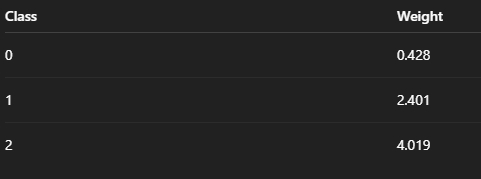

#  4. Search Space


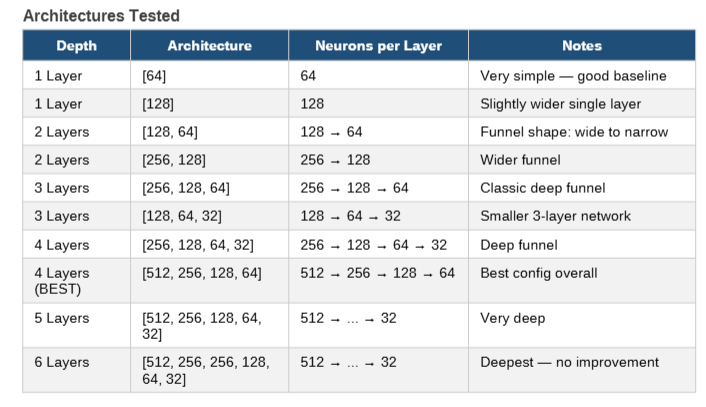

In [5]:
architectures = {
    '1L(64)':              [64],
    '1L(128)':             [128],
    '2L(128-64)':          [128, 64],
    '2L(256-128)':         [256, 128],
    '3L(256-128-64)':      [256, 128, 64],
    '3L(128-64-32)':       [128, 64, 32],
    '4L(256-128-64-32)':   [256, 128, 64, 32],
    '4L(512-256-128-64)':  [512, 256, 128, 64],
    '5L(512-256-128-64-32)':[512, 256, 128, 64, 32],
    '6L(512-256-256-128-64-32)':[512, 256, 256, 128, 64, 32],
}

optimizers = {
    'adam_1e-3':  Adam(learning_rate=1e-3),
    'adam_1e-4':  Adam(learning_rate=1e-4),
    'rmsprop':    RMSprop(learning_rate=1e-3),
    'sgd_mom':    SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
}

activations  = ['relu', 'tanh']
dropout_rates = [0.2, 0.4]
batch_sizes   = [32, 64]

I0000 00:00:1772549619.544070      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


#  5. Build Model


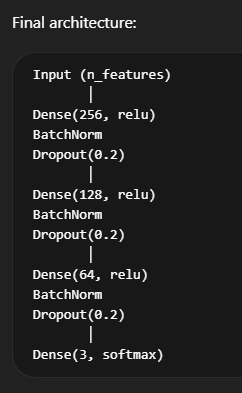

In [ ]:
def build_model(layer_sizes, activation, dropout_rate, optimizer):
    model = Sequential()
    model.add(Dense(layer_sizes[0], activation=activation,
                    input_shape=(n_features,))) #n_features = 21
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for units in layer_sizes[1:]: # for the rest of the layers
        model.add(Dense(units, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

#  6. Experiment Loop


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)
]

all_results = []
best_val_acc = 0
best_config  = None
best_model   = None

total_combinations = len(architectures) * len(optimizers) * len(activations) * len(dropout_rates) * len(batch_sizes)
count = 0

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for arch_name, layers in architectures.items():
    for opt_name, optimizer in optimizers.items():
        for activation in activations:
            for dropout in dropout_rates:
                for batch_size in batch_sizes:
                    count += 1
                    config = f"{arch_name} | {opt_name} | {activation} | drop={dropout} | bs={batch_size}"
                    print(f"\n[{count}/{total_combinations}] {config}")
                    
                    fold_accs = []
                    fold_val_accs = []
                    all_y_true = []
                    all_y_pred = []
                    
                    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
                        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                        
                        scaler = StandardScaler()
                        X_train_sc = scaler.fit_transform(X_train)
                        X_test_sc = scaler.transform(X_test)
                        
                        y_train_cat = to_categorical(y_train, num_classes=3)
                        y_test_cat = to_categorical(y_test, num_classes=3)
                        
                        class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
                        class_weights = dict(enumerate(class_weights_arr))
                        
                        if 'adam_1e-3' in opt_name: opt = Adam(learning_rate=1e-3)
                        elif 'adam_1e-4' in opt_name: opt = Adam(learning_rate=1e-4)
                        elif 'rmsprop' in opt_name: opt = RMSprop(learning_rate=1e-3)
                        else: opt = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
                        
                        model = build_model(layers, activation, dropout, opt)
                        history = model.fit(
                            X_train_sc, y_train_cat,
                            validation_split=0.15,
                            epochs=150,
                            batch_size=batch_size,
                            class_weight=class_weights,
                            callbacks=callbacks,
                            verbose=0
                        )
                        
                        loss, acc = model.evaluate(X_test_sc, y_test_cat, verbose=0)
                        val_acc = max(history.history['val_accuracy'])
                        
                        fold_accs.append(acc)
                        fold_val_accs.append(val_acc)
                        
                        # Generate predictions for this fold
                        y_pred = model.predict(X_test_sc, verbose=0)
                        all_y_true.extend(y_test)
                        all_y_pred.extend(np.argmax(y_pred, axis=1))
                        
                    mean_acc = np.mean(fold_accs)
                    mean_val_acc = np.mean(fold_val_accs)
                    
                    from sklearn.metrics import classification_report, ConfusionMatrixDisplay
                    import matplotlib.pyplot as plt
                    
                    print(f"  Mean Val Acc: {mean_val_acc:.4f} | Mean Test Acc: {mean_acc:.4f}")
                    cm = confusion_matrix(all_y_true, all_y_pred)
                    
                    class_report = classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Suspect', 'Pathologic'])
                    print(f"\n  Classification Report:\n{class_report}")
                    
                    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Suspect', 'Pathologic'])
                    fig, ax = plt.subplots(figsize=(5,5))
                    disp.plot(cmap='Blues', ax=ax)
                    ax.set_title(f"{arch_name} | {opt_name} | {activation}")
                    plt.show()
                    
                    all_results.append({
                        'config':     config,
                        'arch':       arch_name,
                        'optimizer':  opt_name,
                        'activation': activation,
                        'dropout':    dropout,
                        'batch_size': batch_size,
                        'n_layers':   len(layers),
                        'val_acc':    mean_val_acc,
                        'test_acc':   mean_acc,
                    })

                    if mean_val_acc > best_val_acc:
                        best_val_acc = mean_val_acc
                        best_config  = config
                        best_model   = model
                        print(f"  ★ New best model configuration!")

[1/320] 1L(64) | adam_1e-3 | relu | drop=0.2 | bs=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772549671.298645     126 service.cc:152] XLA service 0x7cf3f0002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772549671.298679     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772549671.632947     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772549672.830909     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  ★ New best! Val Acc: 0.9373 | Test Acc: 0.8897
[2/320] 1L(64) | adam_1e-3 | relu | drop=0.2 | bs=64
[3/320] 1L(64) | adam_1e-3 | relu | drop=0.4 | bs=32
[4/320] 1L(64) | adam_1e-3 | relu | drop=0.4 | bs=64
[5/320] 1L(64) | adam_1e-3 | tanh | drop=0.2 | bs=32
[6/320] 1L(64) | adam_1e-3 | tanh | drop=0.2 | bs=64
[7/320] 1L(64) | adam_1e-3 | tanh | drop=0.4 | bs=32
[8/320] 1L(64) | adam_1e-3 | tanh | drop=0.4 | bs=64
[9/320] 1L(64) | adam_1e-4 | relu | drop=0.2 | bs=32
[10/320] 1L(64) | adam_1e-4 | relu | drop=0.2 | bs=64
[11/320] 1L(64) | adam_1e-4 | relu | drop=0.4 | bs=32
[12/320] 1L(64) | adam_1e-4 | relu | drop=0.4 | bs=64
[13/320] 1L(64) | adam_1e-4 | tanh | drop=0.2 | bs=32
[14/320] 1L(64) | adam_1e-4 | tanh | drop=0.2 | bs=64
[15/320] 1L(64) | adam_1e-4 | tanh | drop=0.4 | bs=32
[16/320] 1L(64) | adam_1e-4 | tanh | drop=0.4 | bs=64
[17/320] 1L(64) | rmsprop | relu | drop=0.2 | bs=32
[18/320] 1L(64) | rmsprop | relu | drop=0.2 | bs=64
  ★ New best! Val Acc: 0.9412 | Test Acc: 0.8

# 7. Results table

In [8]:
df_res = pd.DataFrame(all_results).sort_values('val_acc', ascending=False)
print(f"\n{'─'*60}")
print(f"Best config: {best_config}")
print(f"Best val acc: {best_val_acc:.4f}")
print(f"\nTop 10 configurations:")
print(df_res[['arch','optimizer','activation','dropout','batch_size',
              'val_acc','test_acc']].head(10).to_string(index=False))


────────────────────────────────────────────────────────────
Best config: 4L(512-256-128-64) | rmsprop | relu | drop=0.2 | bs=64
Best val acc: 0.9608

Top 10 configurations:
                     arch optimizer activation  dropout  batch_size  val_acc  test_acc
       4L(512-256-128-64)   rmsprop       relu      0.2          64 0.960784  0.920188
               2L(128-64)   rmsprop       relu      0.2          64 0.956863  0.929577
       4L(512-256-128-64)   sgd_mom       relu      0.2          32 0.949020  0.896714
              2L(256-128)   rmsprop       relu      0.4          32 0.949020  0.908451
              2L(256-128)   rmsprop       tanh      0.2          64 0.949020  0.913146
6L(512-256-256-128-64-32) adam_1e-3       tanh      0.2          64 0.949020  0.896714
6L(512-256-256-128-64-32)   rmsprop       relu      0.2          64 0.949020  0.903756
           3L(256-128-64)   rmsprop       relu      0.2          32 0.949020  0.920188
            3L(128-64-32) adam_1e-3       

In [10]:
df_res.to_csv('all_experiment_results.csv', index=False)
from IPython.display import FileLink
FileLink('all_experiment_results.csv')

/kaggle/working/all_experiment_results.csv

#  8. Plots


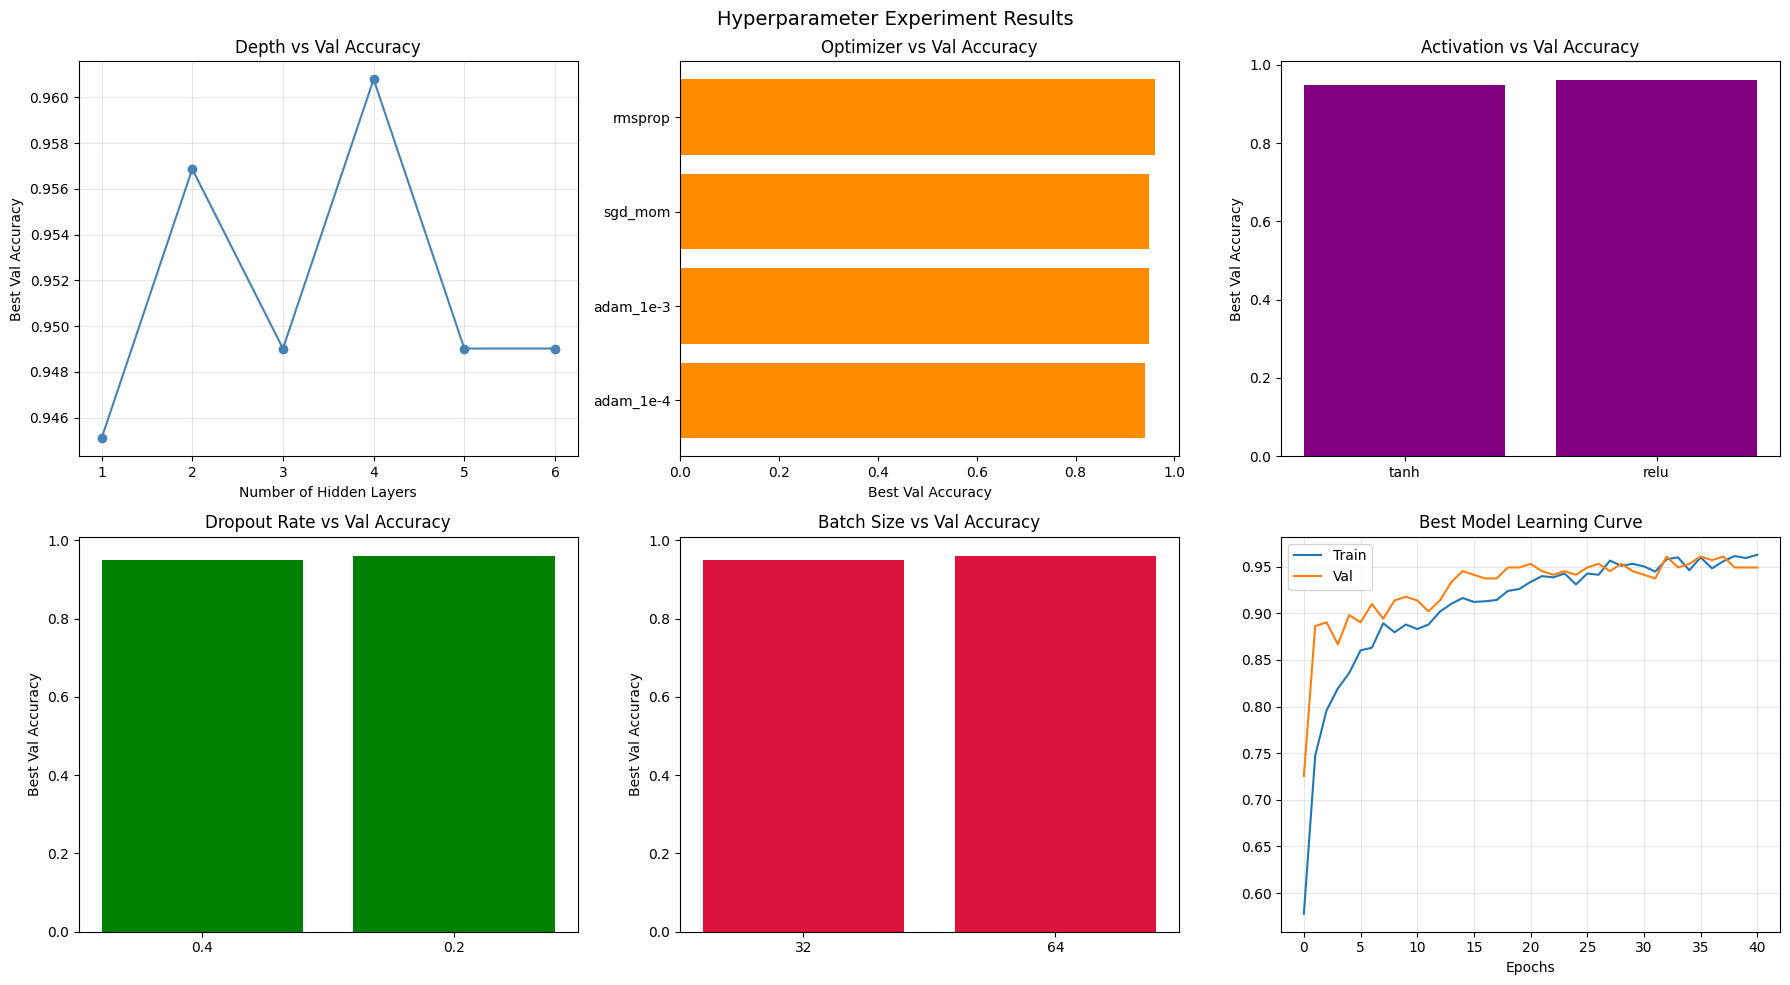

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (a) Depth vs accuracy
depth_acc = df_res.groupby('n_layers')['val_acc'].max()
axes[0,0].plot(depth_acc.index, depth_acc.values, marker='o', color='steelblue')
axes[0,0].set_title('Depth vs Val Accuracy')
axes[0,0].set_xlabel('Number of Hidden Layers')
axes[0,0].set_ylabel('Best Val Accuracy')
axes[0,0].grid(True, alpha=0.3)

# (b) Optimizer comparison
opt_acc = df_res.groupby('optimizer')['val_acc'].max().sort_values()
axes[0,1].barh(opt_acc.index, opt_acc.values, color='darkorange')
axes[0,1].set_title('Optimizer vs Val Accuracy')
axes[0,1].set_xlabel('Best Val Accuracy')

# (c) Activation comparison
act_acc = df_res.groupby('activation')['val_acc'].max().sort_values()
axes[0,2].bar(act_acc.index, act_acc.values, color='purple')
axes[0,2].set_title('Activation vs Val Accuracy')
axes[0,2].set_ylabel('Best Val Accuracy')

# (d) Dropout comparison
drop_acc = df_res.groupby('dropout')['val_acc'].max().sort_values()
axes[1,0].bar([str(d) for d in drop_acc.index], drop_acc.values, color='green')
axes[1,0].set_title('Dropout Rate vs Val Accuracy')
axes[1,0].set_ylabel('Best Val Accuracy')

# (e) Batch size comparison
bs_acc = df_res.groupby('batch_size')['val_acc'].max().sort_values()
axes[1,1].bar([str(b) for b in bs_acc.index], bs_acc.values, color='crimson')
axes[1,1].set_title('Batch Size vs Val Accuracy')
axes[1,1].set_ylabel('Best Val Accuracy')

# (f) Best model learning curve
axes[1,2].plot(best_history.history['accuracy'],     label='Train')
axes[1,2].plot(best_history.history['val_accuracy'], label='Val')
axes[1,2].set_title(f'Best Model Learning Curve')
axes[1,2].set_xlabel('Epochs')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Experiment Results', fontsize=14)
plt.tight_layout()
plt.show()

# 9. Save the best model

In [ ]:
best_model.save('best_mlp_ctg.keras')
joblib.dump(scaler, 'scaler_ctg.pkl') # save the scaler for future use (e.g., inference)    
df_res.to_csv('experiment_results.csv', index=False)
print("\nSaved: best_mlp_ctg.keras | scaler_ctg.pkl | experiment_results.csv")


Saved: best_mlp_ctg.keras | scaler_ctg.pkl | experiment_results.csv


# Interpretation of Hyperparameter Experiment Results

* Depth vs Validation Accuracy:
Increasing the number of hidden layers initially improves validation accuracy, indicating that deeper networks can capture more complex patterns. The best performance occurs with 4 hidden layers, while shallower networks show underfitting due to limited capacity. Increasing depth beyond four layers does not improve performance and slightly reduces accuracy, suggesting over-complexity without additional benefit.

* Optimizer Comparison:
Among the tested optimizers, RMSprop achieves the highest validation accuracy. Its adaptive learning rate helps stabilize gradient updates and improves convergence, especially for deeper architectures.

* Activation Function:
The ReLU activation function performs slightly better than tanh. ReLU mitigates the vanishing gradient problem and allows faster learning, making it more effective for training deeper neural networks.

* Dropout Rate:
A dropout rate of 0.2 gives better performance than 0.4. Lower dropout provides sufficient regularization to reduce overfitting, while a higher dropout rate removes too many neurons and may lead to underfitting.

* Batch Size:
A batch size of 64 achieves slightly higher validation accuracy compared to 32. Larger batch sizes provide more stable gradient estimates and smoother optimization during training.

* Learning Curve:
The training and validation accuracy curves increase steadily and converge closely around 0.95–0.96, indicating that the model learns effectively without severe overfitting. The small gap between the curves suggests good generalization, while early stopping prevents unnecessary training once performance stabilizes.

* Overall Conclusion:
The configuration 4L(512-256-128-64) with RMSprop, ReLU, dropout 0.2, and batch size 64 achieves the best validation accuracy, providing the optimal balance between model capacity, regularization, and generalization performance.